# Nearest neighbourhood classifier

In one sentence, kNN looks for other objects in the neighborhood and assigns the most popular label to new objects. The $k$ in the name is the number of objects that we look for labels in the neighborhood.

In [2]:
import numpy as np
#import tensorflow_datasets as tfds
import pandas as pd
from math import sqrt
from sklearn.metrics import accuracy_score

# Construct a tf.data.Dataset
#ds = tfds.load('titanic', split='train', shuffle_files=True)
#titanic_df = tfds.as_dataframe(ds)

titanic_df = pd.read_csv("titanic-train.csv")
titanic_df.drop("Name", axis=1, inplace=True)
titanic_df.head()

columns = ['Survived','Age', 'Fare']
features = columns[1:]
titanic_df = titanic_df[columns].replace([np.inf, -np.inf], np.nan).dropna()

titanic_df = titanic_df[titanic_df['Fare'] > 30]

survivded_df = titanic_df[titanic_df['Survived']==1].sample(50, random_state=12345)
not_survivded_df = titanic_df[titanic_df['Survived']==0].sample(50, random_state=12345)

train_set = survivded_df.sample(40, random_state=12345)
train_set = pd.concat([train_set, not_survivded_df.sample(40, random_state=12345)])
plot_train_set = train_set
train_set_labels = train_set['Survived']
train_set = train_set[features]


test_set = survivded_df.sample(10, random_state=12345)
test_set = pd.concat([test_set, not_survivded_df.sample(10, random_state=12345)])
plot_test_set = test_set
test_set_labels = test_set['Survived']
test_set = test_set[features]

k = 5

def calculate_distance(x, v):
    """
    This method calculates the Euclidean distance between object x and v.

    :param x: first object
    :param v: second object
    :return: Euclidean distance
    """
    return sqrt((x[0] - v[0]) ** 2 + (x[1] - v[1]) ** 2)

def calculate_distance_matrix():
    """
    This method calculates the distance matrix between all objects.

    :return: A matrix of distances
    """    
    distance_matrix = np.zeros((len(data_set),len(data_set)))
    for i in range(len(data_set)):
        for j in range(len(data_set)):
            distance_matrix[i, j] = calculate_distance(data_set[i], data_set[j])
    return distance_matrix

def find_closest_objects(x, k):
    """
    Finds k closts objects to x.

    :return: A list of objects' ids.
    """        
    distances = []
    i = 0
    for item in train_set.values:
        distances.append([i, calculate_distance(x, item)])
        i = i + 1
    distances=np.array(distances)
    label_ids = distances[distances[:, 1].argsort()][:k,0]
    return [int(item) for item in label_ids]


def predict():
    """
    Assign a label of the most common label in the list of closest objects.

    :return: A list of predictions.
    """        
    predictions = []
    for item in test_set.values:
        label_ids = find_closest_objects(item, k)
        counts = np.bincount(train_set_labels.values[label_ids])
        label = np.argmax(counts)
        predictions.append(label)
    return predictions

In [3]:
train_set

,Age,Fare
269,35.0,135.6333
549,8.0,36.7500
820,52.0,93.5000
325,36.0,135.6333
609,40.0,153.4625
...,...,...
92,46.0,61.1750
27,19.0,263.0000
505,18.0,108.9000
119,2.0,31.2750


In [4]:
label_ids=find_closest_objects( [30,31], 5)
label_ids

[33, 60, 18, 43, 5]

In [50]:
train_set_labels.values[label_ids]

array([1, 0, 1, 0, 1])

In [51]:
np.bincount(train_set_labels.values[label_ids])

array([2, 3])

In [52]:
np.argmax(np.bincount(train_set_labels.values[label_ids]))

1

In [7]:
predictions = predict()
acc = accuracy_score(predictions, test_set_labels)
print(acc)

0.75


In [8]:
plot_train_set.loc[plot_train_set["Survived"] == 1, "Survived"] = "green"
plot_train_set.loc[plot_train_set["Survived"] == 0, "Survived"] = "red"

In [9]:
plot_test_set['predicted'] = predictions

In [11]:
plot_test_set.loc[(plot_test_set["Survived"] == 1) & (plot_test_set["predicted"] == 0), "Survived"] = "black"
plot_test_set.loc[(plot_test_set["Survived"] == 1) & (plot_test_set["predicted"] == 1), "Survived"] = "blue"
plot_test_set.loc[(plot_test_set["Survived"] == 0) & (plot_test_set["predicted"] == 0), "Survived"] = "orange"
plot_test_set.loc[(plot_test_set["Survived"] == 0) & (plot_test_set["predicted"] == 1), "Survived"] = "purple"
plot_test_set.drop(['predicted'],axis=1)

,Survived,Age,Fare
269,blue,35.0,135.6333
549,black,8.0,36.7500
820,black,52.0,93.5000
325,blue,36.0,135.6333
609,blue,40.0,153.4625
670,blue,40.0,39.0000
700,blue,18.0,227.5250
577,blue,39.0,55.9000
537,blue,30.0,106.4250
291,blue,19.0,91.0792


In [12]:
plot_set = pd.concat([plot_test_set, plot_train_set])

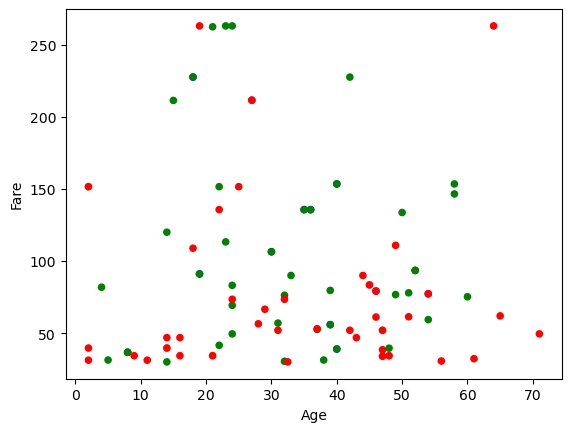

In [13]:
res = plot_set.plot.scatter(x='Age',y='Fare',c='Survived').get_figure()

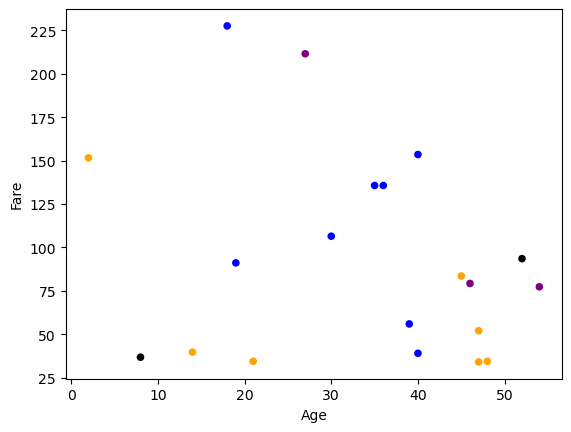

In [14]:
res = plot_test_set.plot.scatter(x='Age',y='Fare',c='Survived').get_figure()

### How can we improve that?